In [14]:
from google.colab import files
uploaded = files.upload()

Saving MASTER MENU SPREADSHEET.xlsx to MASTER MENU SPREADSHEET (1).xlsx


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### LOADING DATASET

In [16]:
df = pd.read_excel('MASTER MENU SPREADSHEET.xlsx', sheet_name='Order Data  ')
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)

Shape: (880, 22)
         ORDER ID       DATE      DAY CATEGORY(BREAKFAST/LUNCH/SNACKS/DINNER)  \
0  CS-250331-0219 2025-04-01  Tuesday                                   Lunch   
1  CS-250331-0242 2025-04-01  Tuesday                                  Dinner   
2  CS-250331-0232 2025-04-01  Tuesday                                  Dinner   
3  CS-250331-0246 2025-04-01  Tuesday                                  Dinner   
4  CS-250331-0236 2025-04-01  Tuesday                               Breakfast   

  TYPE(SUBSCRIPTION/REGULAR)  \
0               SUBSCRIPTION   
1               SUBSCRIPTION   
2               SUBSCRIPTION   
3               SUBSCRIPTION   
4               SUBSCRIPTION   

                                           DISH NAME  QUANTITY  ORDER VALUE  \
0  Rice(750ml), Sambar(250ml),Vendakkai fry(100ml...         1        129.0   
1      Egg kothu chappathi(500ml) with gravy (100ml)         1        117.0   
2       Ragi idiyapam(4no.s) with white kurma(250ml)         1    

In [17]:
df['DATE'] = pd.to_datetime(df['DATE'])

daily = df.groupby('DATE')['ORDER ID'].count().reset_index()
daily.columns = ['Date', 'Orders']

### DAILY ORDER COUNT AND TREND

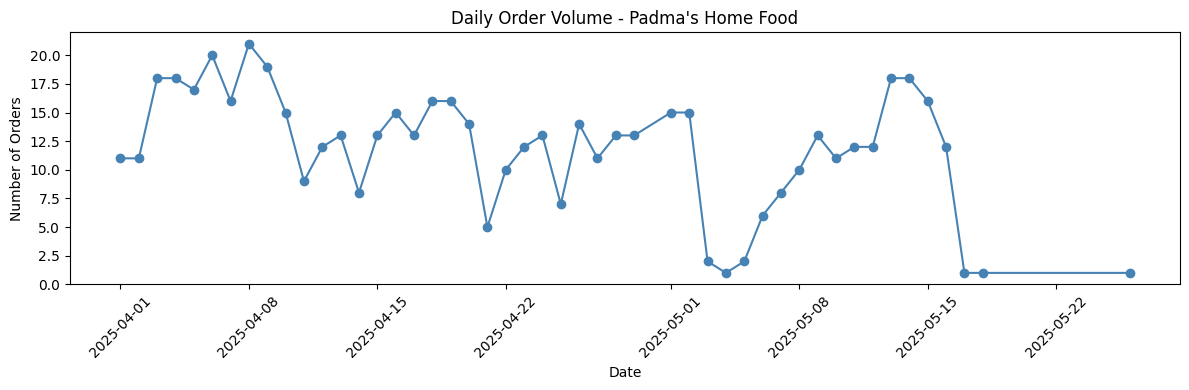

Mean orders/day: 11.81
Std deviation: 5.306183666853512


In [18]:
plt.figure(figsize=(12,4))
plt.plot(daily['Date'], daily['Orders'], marker='o', color='steelblue')
plt.title('Daily Order Volume - Padma\'s Home Food')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('daily_orders_trend.png', dpi=150)
plt.show()
print("Mean orders/day:", daily['Orders'].mean().round(2))
print("Std deviation:", daily['Orders'].std())

### DAY OF WEEK ANALYSIS

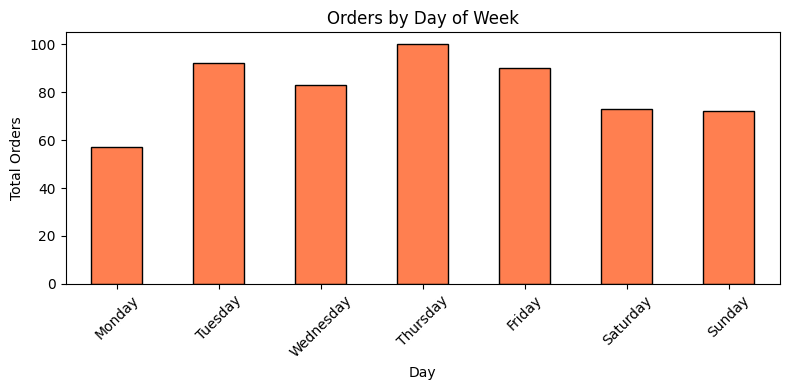

In [19]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df.groupby('DAY')['ORDER ID'].count().reindex(day_order)

plt.figure(figsize=(8,4))
day_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('orders_by_day.png', dpi=150)
plt.show()

### MEAL CATEGORY ANALYSIS

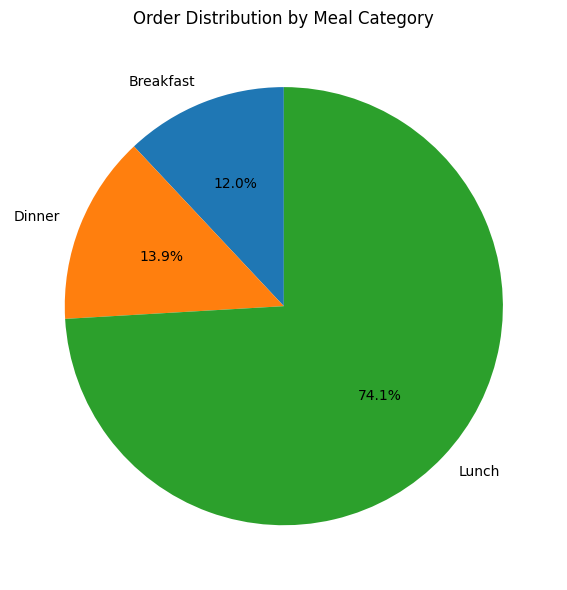

In [20]:
cat_col = 'CATEGORY(BREAKFAST/LUNCH/SNACKS/DINNER)'
meal_counts = df.groupby(cat_col)['ORDER ID'].count()

plt.figure(figsize=(6,6))
meal_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Order Distribution by Meal Category')
plt.ylabel('')
plt.tight_layout()
plt.savefig('meal_category.png', dpi=150)
plt.show()

### EXPONENTIAL SMOOTHING FORECAST

Overall MAPE: 120.7 %


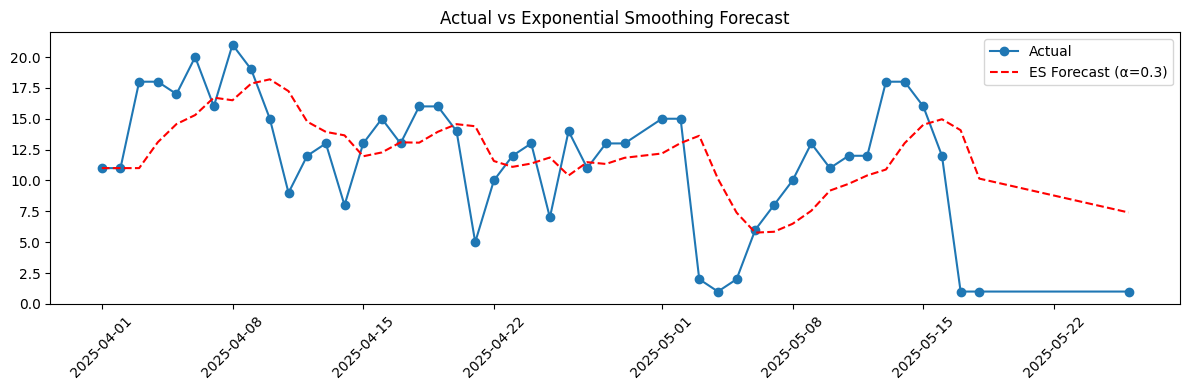

In [21]:
alpha = 0.3
daily['ES_Forecast'] = 0.0
daily.loc[0, 'ES_Forecast'] = daily.loc[0, 'Orders']

for i in range(1, len(daily)):
    daily.loc[i, 'ES_Forecast'] = alpha * daily.loc[i-1, 'Orders'] + (1-alpha) * daily.loc[i-1, 'ES_Forecast']

# MAPE
daily['MAPE'] = abs(daily['Orders'] - daily['ES_Forecast']) / daily['Orders'] * 100
print("Overall MAPE:", daily['MAPE'][1:].mean().round(2), "%")

plt.figure(figsize=(12,4))
plt.plot(daily['Date'], daily['Orders'], label='Actual', marker='o')
plt.plot(daily['Date'], daily['ES_Forecast'], label='ES Forecast (α=0.3)', linestyle='--', color='red')
plt.title('Actual vs Exponential Smoothing Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('es_forecast.png', dpi=150)
plt.show()

### REGULAR Vs SUBSCRIPTION

  TYPE(SUBSCRIPTION/REGULAR)  Orders  Revenue
0                    REGULAR     269  81216.0
1               SUBSCRIPTION     298  36770.0


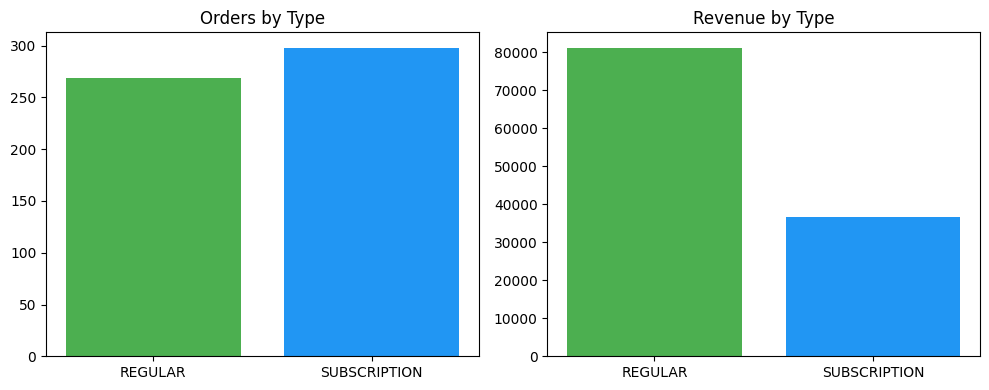

In [22]:
type_col = 'TYPE(SUBSCRIPTION/REGULAR)'
type_rev = df.groupby(type_col).agg(
    Orders=('ORDER ID','count'),
    Revenue=('ORDER VALUE','sum')
).reset_index()
print(type_rev)

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].bar(type_rev[type_col], type_rev['Orders'], color=['#4CAF50','#2196F3'])
ax[0].set_title('Orders by Type')
ax[1].bar(type_rev[type_col], type_rev['Revenue'], color=['#4CAF50','#2196F3'])
ax[1].set_title('Revenue by Type')
plt.tight_layout()
plt.savefig('order_type.png', dpi=150)
plt.show()

In [23]:
daily.to_excel('forecasting_output.xlsx', index=False)
print("Saved! Download from Files panel on left side.")

Saved! Download from Files panel on left side.
